In [3]:
import pandas as pd

df = pd.read_csv("../data/tickets.csv")

df.head()

,ticket_id,customer_name,customer_email,product,category,issue_description,resolution_notes,priority,status,channel,...,ticket_resolved_date,escalated,sla_breached,operating_system,browser,payment_method,language,preferred_contact_time,issue_complexity_score,customer_segment
0,1,Patricia Smith,patricia.smith760@outlook.com,Web Portal,Account Suspension,The payment was deducted from my bank account ...,Data synchronization restored after backend se...,Urgent,Open,Email,...,2023-05-20,No,Yes,MacOS,Edge,PayPal,French,Afternoon,4,Small Business
1,2,Patricia Williams,patricia.williams390@gmail.com,Mobile App,Performance Issue,I found a bug in the latest update affecting r...,Provided step-by-step troubleshooting instruct...,Urgent,Closed,Email,...,2024-01-19,Yes,Yes,Windows,Firefox,PayPal,English,Afternoon,2,Small Business
2,3,William Anderson,william.anderson651@outlook.com,Web Portal,Performance Issue,The application crashes whenever I try to uplo...,Provided step-by-step troubleshooting instruct...,Medium,Closed,Chat,...,2022-12-05,Yes,Yes,Windows,Safari,Bank Transfer,French,Morning,4,Corporate
3,4,David Miller,david.miller672@icloud.com,Payment Gateway,Subscription Cancellation,My subscription was cancelled without my reque...,Provided step-by-step troubleshooting instruct...,Medium,Closed,Social Media,...,2024-04-04,Yes,No,Windows,Chrome,Credit Card,Spanish,Afternoon,7,Corporate
4,5,Robert Gonzalez,robert.gonzalez391@hotmail.com,Web Portal,Feature Request,The system is not syncing data across devices ...,We have reset the account credentials and advi...,High,Pending Customer,Email,...,2024-08-24,Yes,No,Linux,NaN,Debit Card,Spanish,Evening,3,Corporate


In [4]:
df.shape

(200000, 30)

In [5]:
df.columns

Index(['ticket_id', 'customer_name', 'customer_email', 'product', 'category',
       'issue_description', 'resolution_notes', 'priority', 'status',
       'channel', 'region', 'customer_age', 'customer_gender',
       'subscription_type', 'customer_tenure_months', 'previous_tickets',
       'customer_satisfaction_score', 'first_response_time_hours',
       'resolution_time_hours', 'ticket_created_date', 'ticket_resolved_date',
       'escalated', 'sla_breached', 'operating_system', 'browser',
       'payment_method', 'language', 'preferred_contact_time',
       'issue_complexity_score', 'customer_segment'],
      dtype='object')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Hanna\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


   ticket_id  topic sentiment
0          1     40  negative
1          2     47  positive
2          3     52   neutral
3          4     24   neutral
4          5     58   neutral
Topic 62: 123 tickets
sentiment
neutral    123
Name: count, dtype: int64
------------------------------
Topic 25: 120 tickets
sentiment
neutral    120
Name: count, dtype: int64
------------------------------
Topic 22: 118 tickets
sentiment
neutral    118
Name: count, dtype: int64
------------------------------
Topic 84: 115 tickets
sentiment
neutral    115
Name: count, dtype: int64
------------------------------
Topic 83: 114 tickets
sentiment
neutral    114
Name: count, dtype: int64
------------------------------


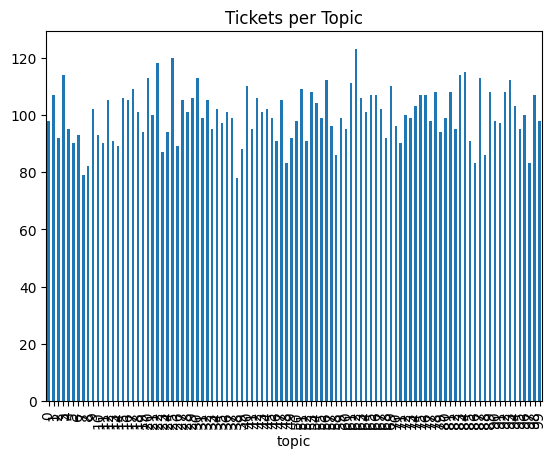

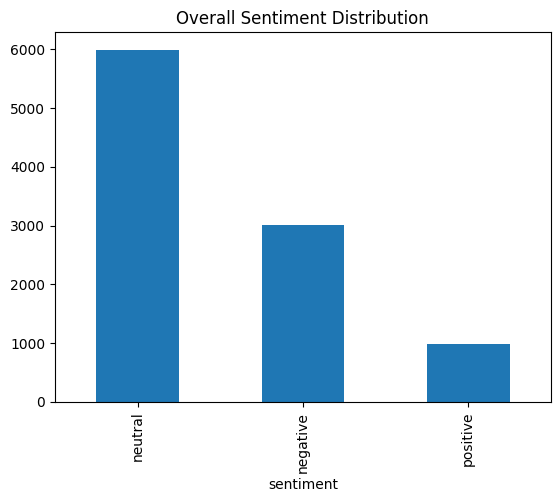

In [17]:
# AI Support Ticket Analyzer - Full Pipeline

# Import libraries
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from textblob import TextBlob
from sklearn.feature_extraction.text import TfidfVectorizer
import hdbscan
import matplotlib.pyplot as plt

# Download stopwords
nltk.download('stopwords')

# Load CSV with relevant columns for analysis
cols = ['ticket_id', 'product', 'category', 'issue_description', 'resolution_notes', 'ticket_created_date']
df = pd.read_csv("../data/tickets.csv", usecols=cols, nrows=10000)  # use all rows later

# Combine issue description and resolution notes, then clean text
def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r"[^a-zA-Z0-9\s]", "", text)  # remove punctuation
    text = re.sub(r"\s+", " ", text)  # remove extra spaces
    return text.strip()

df['clean_text'] = df['issue_description'].fillna("") + " " + df['resolution_notes'].fillna("")
df['clean_text'] = df['clean_text'].apply(clean_text)

# Remove common English stopwords to focus on meaningful words
stop_words = set(stopwords.words('english'))
df['clean_text'] = df['clean_text'].apply(lambda x: " ".join([w for w in x.split() if w not in stop_words]))

# Compute sentiment for each ticket using TextBlob
# Polarity: -1 (negative) to +1 (positive)
# Categorize as positive, negative, or neutral
def classify_sentiment(text):
    blob = TextBlob(text)
    polarity = blob.sentiment.polarity
    if polarity > 0.1:
        return "positive"
    elif polarity < -0.1:
        return "negative"
    else:
        return "neutral"

df['sentiment'] = df['issue_description'].astype(str).apply(classify_sentiment)

# Convert text into numerical vectors using TF-IDF for clustering
# TF-IDF captures the importance of words in each ticket
vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(df['clean_text'])

# Cluster similar tickets into topics using HDBSCAN
# HDBSCAN automatically detects the number of clusters
# topic = -1 means no cluster / outlier
clusterer = hdbscan.HDBSCAN(min_cluster_size=20, metric='euclidean')
df['topic'] = clusterer.fit_predict(X.toarray())

# Display the first few tickets with assigned topic and sentiment
print(df[['ticket_id', 'topic', 'sentiment']].head())

# Analyze the most common topics and sentiment distribution
top_topics = df['topic'].value_counts().head(5).index.tolist()
for t in top_topics:
    subset = df[df['topic'] == t]
    print(f"Topic {t}: {len(subset)} tickets")
    print(subset['sentiment'].value_counts())
    print("-" * 30)

# Visualize number of tickets per topic
df.groupby('topic')['ticket_id'].count().plot(kind='bar', title='Tickets per Topic')
plt.show()

# Visualize overall sentiment distribution
df['sentiment'].value_counts().plot(kind='bar', title='Overall Sentiment Distribution')
plt.show()

df.to_csv("../data/tickets_processed.csv", index=False)